# Лабораторная работа №1
## Исследовательский анализ данных (EDA) и подготовка данных

**Дисциплина:** Анализ данных и искусственный интеллект

**Датасет:** [Student Mental Health & Burnout (1M)](https://www.kaggle.com/datasets/ayeshasiddiqa123/student-health) — Kaggle

## 1. Предметная область и цель анализа

### Предметная область

Датасет описывает **ментальное здоровье и выгорание студентов**. Каждая запись содержит информацию о студенте: демографические данные (возраст, пол, курс обучения), учебную нагрузку, показатели психического состояния (стресс, тревожность, депрессия), образ жизни (сон, физическая активность, экранное время) и социальные факторы (поддержка, финансовый стресс, ожидания семьи).

Проблема ментального здоровья студентов актуальна: высокая учебная нагрузка, экзаменационное давление и недостаток сна ведут к выгоранию и риску отчисления.

### Цель анализа

1. Выявить ключевые факторы, влияющие на уровень выгорания (`burnout_score`) и индекс ментального здоровья (`mental_health_index`) студентов.
2. Определить группы студентов с наибольшим риском отчисления (`dropout_risk`).
3. Исследовать взаимосвязи между учебной нагрузкой, образом жизни и психическим состоянием.

## 2. Загрузка и первичный обзор данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

%matplotlib inline

In [2]:
df = pd.read_csv('student_mental_health_burnout_1M.csv')
print(f'Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} столбцов')

Размер датасета: 1,000,000 строк, 20 столбцов


In [3]:
df.head(10)

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000
5,29,Female,3,7.697210,8.460408,68.332246,5.464786,1.720314,2.313338,6.574379,0.000000,3.928159,3.869208,3.918780,2.872448,10.000000,1.472916,6.603990,Low,2.731063
6,21,Female,3,7.012742,7.287667,75.180787,2.989919,1.445026,0.000000,3.660558,1.975417,7.048037,6.502918,6.769425,4.811232,1.130250,1.798278,8.370524,Low,0.868724
7,23,Female,2,6.946342,7.501935,80.894906,5.007514,2.725366,0.782428,7.355030,0.000000,4.270020,3.618190,2.170218,5.428043,6.732679,1.939261,6.944656,Low,1.578051
8,26,Male,4,6.535580,6.910609,77.236996,5.802609,4.451598,2.034520,5.157029,2.138839,3.340810,1.534403,2.106578,6.578510,5.831068,3.535596,5.733121,Medium,3.492676
9,19,Female,3,5.292718,6.621179,73.808178,4.307115,2.435479,1.127562,6.281727,0.991039,9.161838,4.628498,2.059240,3.826165,4.525573,0.000000,7.208242,Low,0.446036


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [5]:
df.describe().round(2)

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00
mean,23.00,2.50,5.00,6.00,71.00,4.25,2.99,1.27,6.50,3.01,5.00,5.02,5.04,5.00,5.98,1.78,7.02,1.32
std,3.74,1.12,1.99,1.55,5.66,1.68,1.51,1.22,1.47,1.46,1.98,1.96,2.16,1.98,1.96,1.66,1.31,1.34
min,17.00,1.00,0.00,1.00,42.37,0.00,0.00,0.00,3.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.31,0.00
25%,20.00,2.00,3.65,4.94,67.18,3.10,1.92,0.01,5.49,1.99,3.65,3.65,3.49,3.66,4.65,0.12,6.14,0.00
50%,23.00,3.00,5.00,6.00,71.00,4.24,2.97,1.05,6.50,3.00,5.00,5.00,5.00,5.00,6.00,1.50,7.07,1.01
75%,26.00,4.00,6.35,7.05,74.82,5.39,4.01,2.09,7.51,4.01,6.35,6.35,6.51,6.35,7.35,2.89,7.96,2.17
max,29.00,4.00,14.00,10.00,97.25,10.00,10.00,8.53,10.00,7.00,10.00,12.00,14.00,10.00,10.00,10.00,10.00,9.33


In [6]:
# Категориальные признаки
print('Уникальные значения gender:', df['gender'].unique())
print('Уникальные значения risk_level:', df['risk_level'].unique())
print('Уникальные значения academic_year:', sorted(df['academic_year'].unique()))
print()
print('Распределение gender:')
print(df['gender'].value_counts())
print()
print('Распределение risk_level:')
print(df['risk_level'].value_counts())
print()
print('Распределение academic_year:')
print(df['academic_year'].value_counts().sort_index())

Уникальные значения gender: ['Male' 'Female' 'Other']
Уникальные значения risk_level: ['Low' 'High' 'Medium']
Уникальные значения academic_year: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Распределение gender:
gender
Female    480070
Male      479643
Other      40287
Name: count, dtype: int64

Распределение risk_level:
risk_level
Low       766645
Medium    218275
High       15080
Name: count, dtype: int64

Распределение academic_year:
academic_year
1    249671
2    249886
3    250433
4    250010
Name: count, dtype: int64


## 3. Анализ пропусков и выбросов

### 3.1 Анализ пропусков

In [7]:
# Подсчёт пропусков по каждому столбцу
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент (%)': missing_pct})
print(missing_df)
print(f'\nОбщее количество пропусков: {missing.sum()}')

                      Пропуски  Процент (%)
age                          0          0.0
gender                       0          0.0
academic_year                0          0.0
study_hours_per_day          0          0.0
exam_pressure                0          0.0
academic_performance         0          0.0
stress_level                 0          0.0
anxiety_score                0          0.0
depression_score             0          0.0
sleep_hours                  0          0.0
physical_activity            0          0.0
social_support               0          0.0
screen_time                  0          0.0
internet_usage               0          0.0
financial_stress             0          0.0
family_expectation           0          0.0
burnout_score                0          0.0
mental_health_index          0          0.0
risk_level                   0          0.0
dropout_risk                 0          0.0

Общее количество пропусков: 0


Пропуски в данных отсутствуют — датасет полностью заполнен.

### 3.2 Анализ выбросов

Используем два метода:
1. **Метод межквартильного размаха (IQR)**
2. **Метод Z-оценки**

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

def detect_outliers_iqr(data: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Обнаружение выбросов методом IQR для указанных столбцов."""
    q1 = data[columns].quantile(0.25)
    q3 = data[columns].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (data[columns] < lower) | (data[columns] > upper)
    result = pd.DataFrame({
        'Выбросов (IQR)': outlier_mask.sum(),
        'Процент (%)': (outlier_mask.sum() / len(data) * 100).round(2),
        'Нижняя граница': lower.round(2),
        'Верхняя граница': upper.round(2)
    })
    return result

def detect_outliers_zscore(data: pd.DataFrame, columns: list, threshold: float = 3.0) -> pd.DataFrame:
    """Обнаружение выбросов методом Z-оценки для указанных столбцов."""
    z_scores = np.abs(stats.zscore(data[columns], nan_policy='omit'))
    outlier_mask = z_scores > threshold
    result = pd.DataFrame({
        'Выбросов (Z-score)': outlier_mask.sum(),
        'Процент (%)': (outlier_mask.sum() / len(data) * 100).round(2)
    }, index=columns)
    return result

iqr_outliers = detect_outliers_iqr(df, numerical_cols)
print('=== Метод IQR ===')
print(iqr_outliers)
print()

=== Метод IQR ===
                      Выбросов (IQR)  Процент (%)  Нижняя граница  Верхняя граница
age                                0         0.00           11.00            35.00
academic_year                      0         0.00           -1.00             7.00
study_hours_per_day             3491         0.35           -0.39            10.39
exam_pressure                   2809         0.28            1.78            10.21
academic_performance            6944         0.69           55.72            86.28
stress_level                    3287         0.33           -0.32             8.81
anxiety_score                   3409         0.34           -1.21             7.15
depression_score                3351         0.34           -3.12             5.21
sleep_hours                        0         0.00            2.46            10.55
physical_activity                  0         0.00           -1.04             7.04
social_support                     0         0.00           -0.40    

In [9]:
zscore_outliers = detect_outliers_zscore(df, numerical_cols)
print('=== Метод Z-оценки (порог = 3) ===')
print(zscore_outliers)

=== Метод Z-оценки (порог = 3) ===
                      Выбросов (Z-score)  Процент (%)
age                                34196         3.42
academic_year                      34196         3.42
study_hours_per_day                34196         3.42
exam_pressure                      34196         3.42
academic_performance               34196         3.42
stress_level                       34196         3.42
anxiety_score                      34196         3.42
depression_score                   34196         3.42
sleep_hours                        34196         3.42
physical_activity                  34196         3.42
social_support                     34196         3.42
screen_time                        34196         3.42
internet_usage                     34196         3.42
financial_stress                   34196         3.42
family_expectation                 34196         3.42
burnout_score                      34196         3.42
mental_health_index                34196       

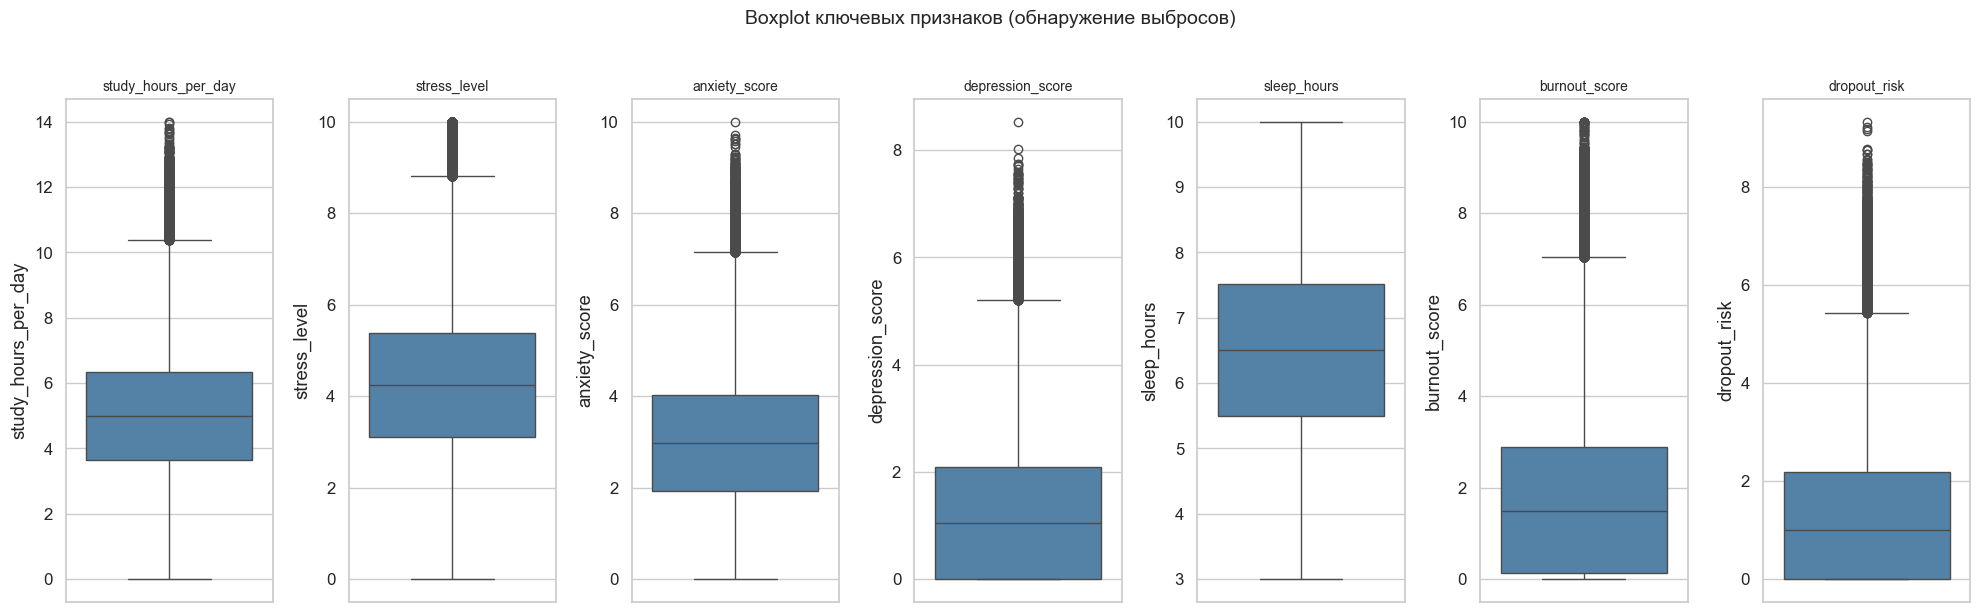

In [10]:
# Визуализация выбросов — boxplot для ключевых признаков
key_cols = ['study_hours_per_day', 'stress_level', 'anxiety_score', 
            'depression_score', 'sleep_hours', 'burnout_score', 'dropout_risk']

fig, axes = plt.subplots(1, len(key_cols), figsize=(20, 6))
for ax, col in zip(axes, key_cols):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
fig.suptitle('Boxplot ключевых признаков (обнаружение выбросов)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Очистка и преобразование данных

In [11]:
# Проверка дубликатов
duplicates_count = df.duplicated().sum()
print(f'Количество дубликатов: {duplicates_count}')

if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f'Размер после удаления дубликатов: {df.shape}')

Количество дубликатов: 0


In [12]:
# Обработка выбросов: ограничение (winsorization) по IQR для числовых признаков
def clip_outliers_iqr(data: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Ограничение выбросов по границам IQR (winsorization)."""
    data = data.copy()
    q1 = data[columns].quantile(0.25)
    q3 = data[columns].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    data[columns] = data[columns].clip(lower=lower, upper=upper, axis=1)
    return data

# Столбцы для клиппинга (исключаем age и academic_year — дискретные)
cols_to_clip = [c for c in numerical_cols if c not in ['age', 'academic_year']]
df_clean = clip_outliers_iqr(df, cols_to_clip)

print('Выбросы ограничены по IQR-границам.')
print(f'Размер данных: {df_clean.shape}')

Выбросы ограничены по IQR-границам.
Размер данных: (1000000, 20)


In [13]:
# Преобразование типов
# gender и risk_level — в category для экономии памяти
df_clean['gender'] = df_clean['gender'].astype('category')
df_clean['risk_level'] = df_clean['risk_level'].astype('category')

# academic_year — ordinal, оставляем int
print('Типы данных после преобразования:')
print(df_clean.dtypes)
print(f'\nПотребление памяти: {df_clean.memory_usage(deep=True).sum() / 1e6:.1f} МБ')

Типы данных после преобразования:
age                        int64
gender                  category
academic_year              int64
study_hours_per_day      float64
exam_pressure            float64
academic_performance     float64
stress_level             float64
anxiety_score            float64
depression_score         float64
sleep_hours              float64
physical_activity        float64
social_support           float64
screen_time              float64
internet_usage           float64
financial_stress         float64
family_expectation       float64
burnout_score            float64
mental_health_index      float64
risk_level              category
dropout_risk             float64
dtype: object

Потребление памяти: 146.0 МБ


## 5. Feature Engineering

Создадим **5 новых признаков** на основе предметной области:

In [14]:
# 1. Индекс психологической нагрузки: комбинация стресса, тревожности и депрессии
df_clean['psych_load_index'] = (
    df_clean['stress_level'] + df_clean['anxiety_score'] + df_clean['depression_score']
) / 3

# 2. Баланс сна и учёбы: отношение часов сна к часам учёбы
df_clean['sleep_study_ratio'] = df_clean['sleep_hours'] / df_clean['study_hours_per_day'].replace(0, np.nan)
df_clean['sleep_study_ratio'] = df_clean['sleep_study_ratio'].fillna(0)

# 3. Цифровая нагрузка: сумма экранного времени и интернет-использования
df_clean['digital_load'] = df_clean['screen_time'] + df_clean['internet_usage']

# 4. Индекс внешнего давления: комбинация экзаменационного давления, финансового стресса и ожиданий семьи
df_clean['external_pressure'] = (
    df_clean['exam_pressure'] + df_clean['financial_stress'] + df_clean['family_expectation']
) / 3

# 5. Категория возраста
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[16, 19, 22, 25, 30],
    labels=['17-19', '20-22', '23-25', '26-29']
)

print('Новые признаки:')
print(df_clean[['psych_load_index', 'sleep_study_ratio', 'digital_load', 
                'external_pressure', 'age_group']].describe().round(2))

Новые признаки:
       psych_load_index  sleep_study_ratio  digital_load  external_pressure
count        1000000.00         1000000.00    1000000.00         1000000.00
mean               2.83               2.20         10.05               5.66
std                1.28             118.68          3.99               1.06
min                0.00               0.00          2.00               1.09
25%                1.91               0.96          7.22               4.94
50%                2.78               1.29         10.01               5.67
75%                3.70               1.82         12.78               6.39
max                7.06          102179.40         21.43              10.00


In [15]:
print(f'Итоговый размер данных: {df_clean.shape[0]:,} строк, {df_clean.shape[1]} столбцов')
df_clean.head()

Итоговый размер данных: 1,000,000 строк, 25 столбцов


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk,psych_load_index,sleep_study_ratio,digital_load,external_pressure,age_group
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601,2.793131,1.229531,9.976958,4.506664,23-25
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000,0.116496,1.333413,8.999104,4.641395,20-22
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941,2.251124,3.467042,8.487212,5.667323,26-29
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.036466,4.649042,High,5.380592,5.192304,0.992224,13.235989,6.719144,26-29
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000,0.985718,2.739142,10.038049,4.776181,23-25


## 6. Визуальный анализ зависимостей

### 6.1 Распределения ключевых признаков

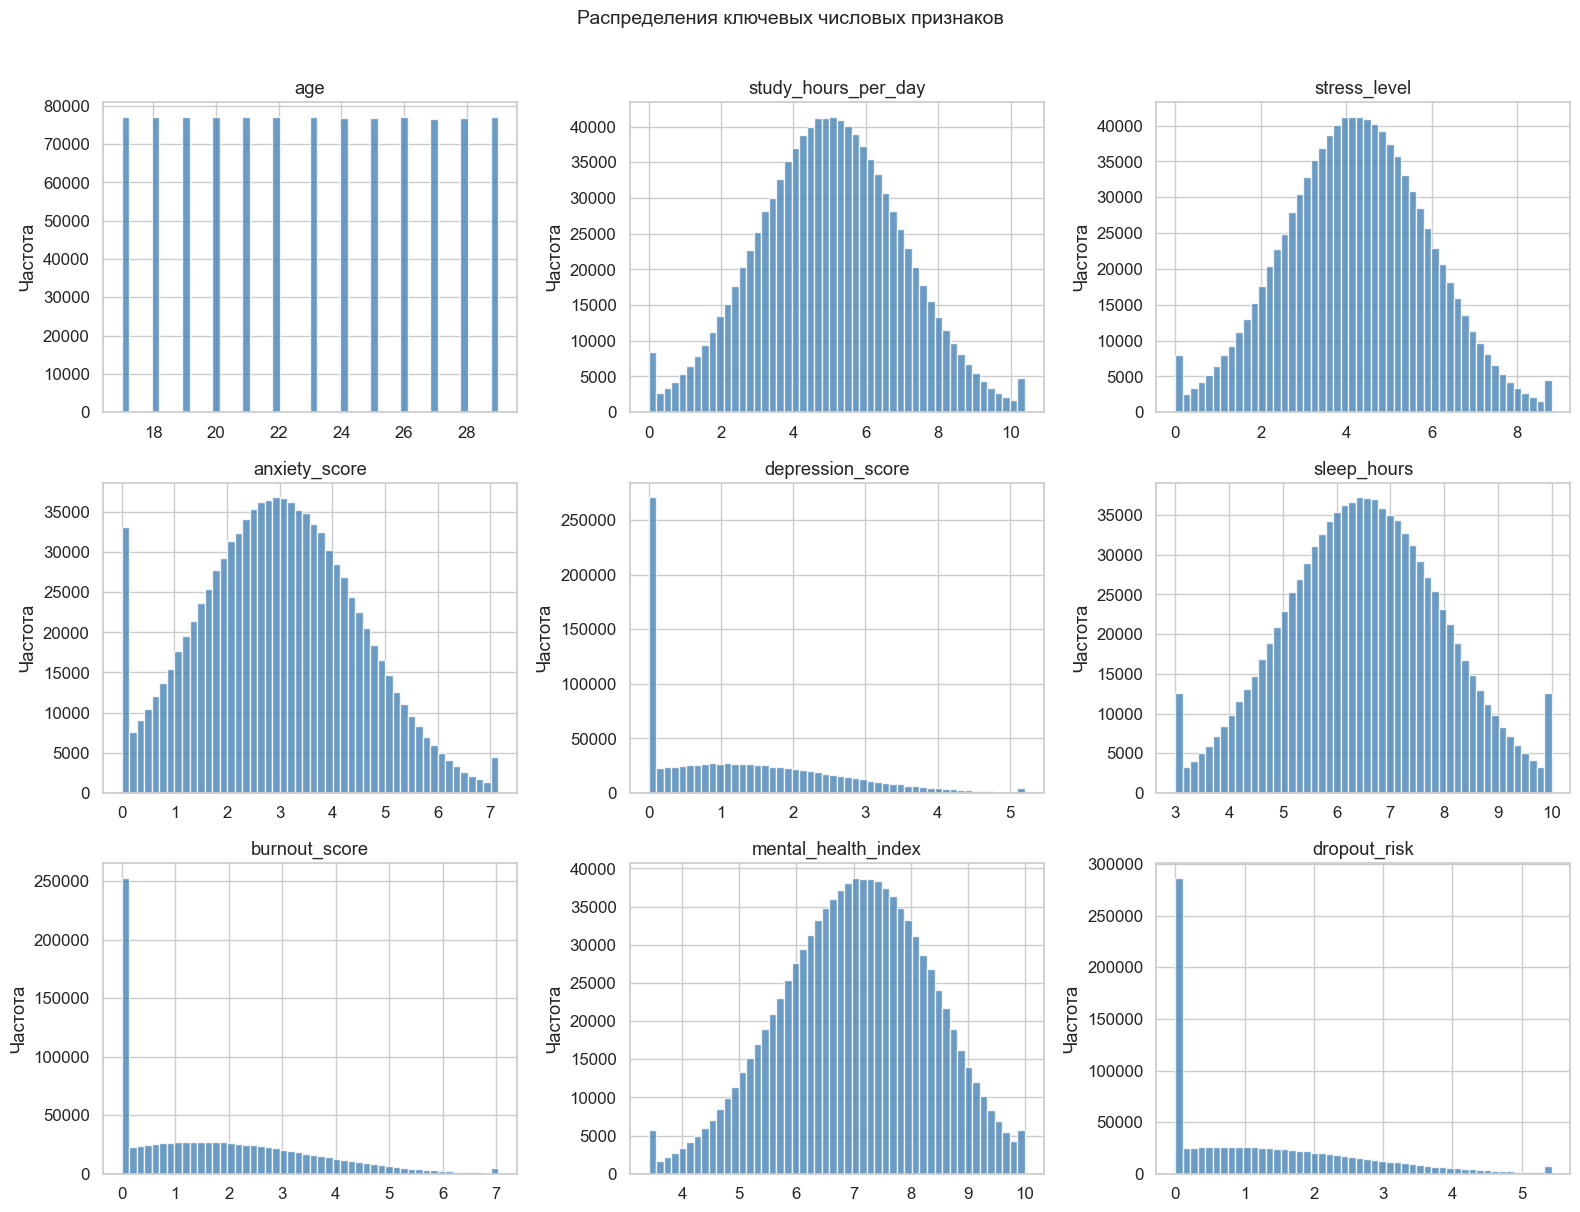

In [16]:
# Гистограммы для числовых признаков
hist_cols = ['age', 'study_hours_per_day', 'stress_level', 'anxiety_score',
             'depression_score', 'sleep_hours', 'burnout_score', 'mental_health_index', 'dropout_risk']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.ravel(), hist_cols):
    ax.hist(df_clean[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col)
    ax.set_ylabel('Частота')
fig.suptitle('Распределения ключевых числовых признаков', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Корреляционная матрица

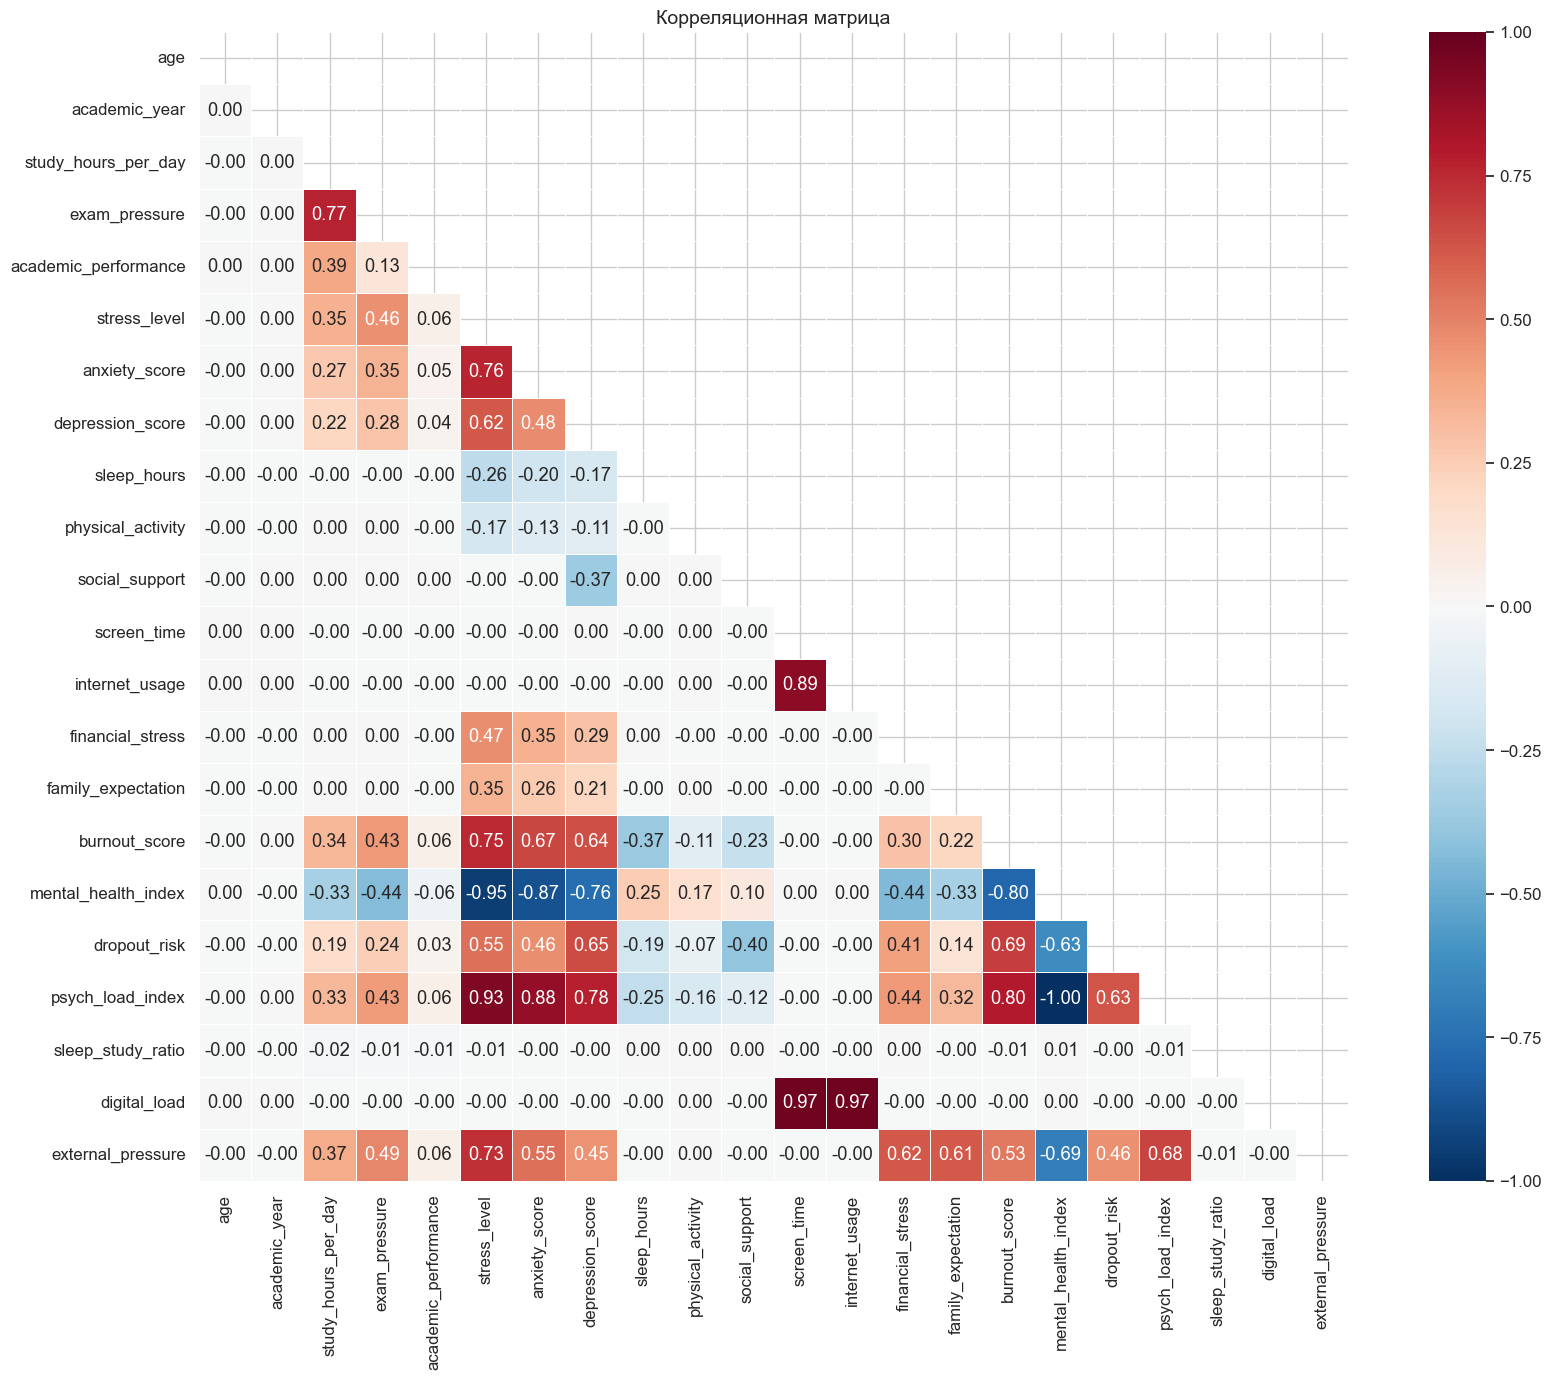

In [17]:
# Корреляция числовых признаков (включая новые)
corr_cols = numerical_cols + ['psych_load_index', 'sleep_study_ratio', 'digital_load', 'external_pressure']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Корреляционная матрица', fontsize=14)
plt.tight_layout()
plt.show()

### 6.3 Зависимость выгорания от факторов

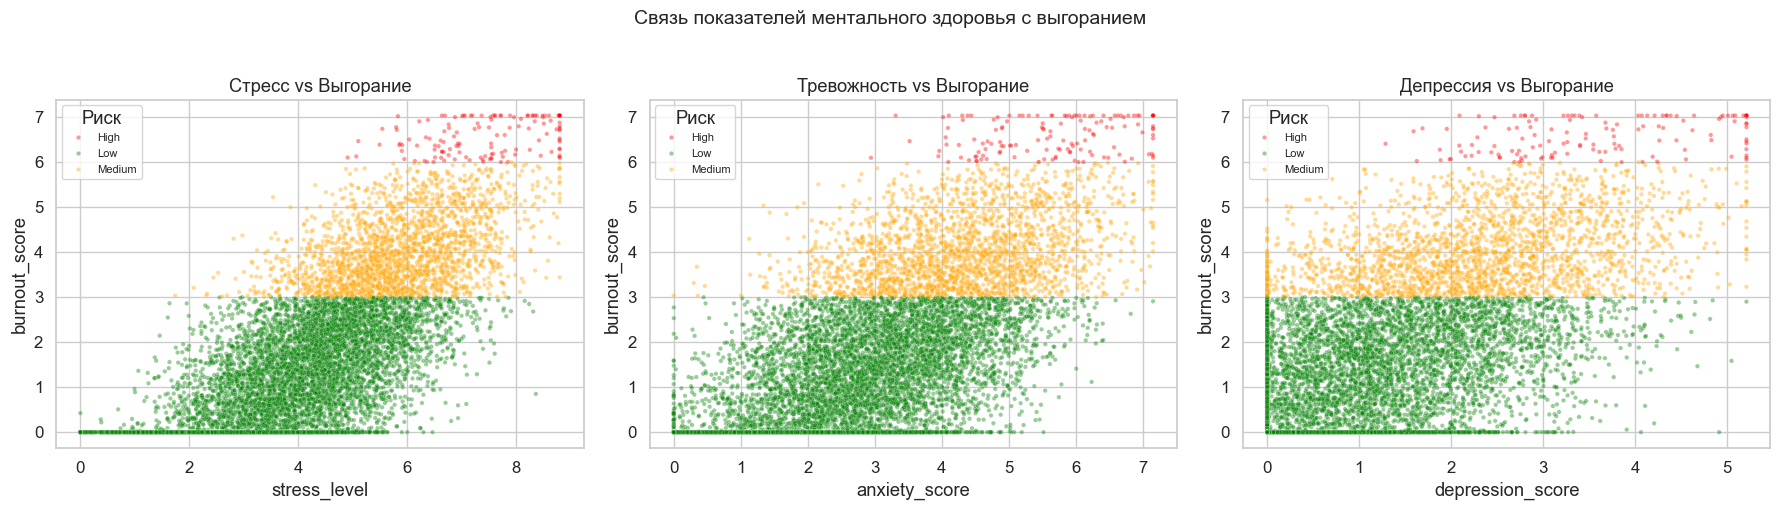

In [18]:
# Scatter-plot: стресс vs. выгорание, цвет — уровень риска
# Используем выборку для читаемости scatter-plot
sample = df_clean.sample(n=10_000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_pairs = [
    ('stress_level', 'burnout_score', 'Стресс vs Выгорание'),
    ('anxiety_score', 'burnout_score', 'Тревожность vs Выгорание'),
    ('depression_score', 'burnout_score', 'Депрессия vs Выгорание')
]

for ax, (x, y, title) in zip(axes, scatter_pairs):
    sns.scatterplot(data=sample, x=x, y=y, hue='risk_level',
                    palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'},
                    alpha=0.4, s=10, ax=ax)
    ax.set_title(title)
    ax.legend(title='Риск', fontsize=8)

plt.suptitle('Связь показателей ментального здоровья с выгоранием', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Распределение по категориям

C:\Users\user\AppData\Local\Temp\ipykernel_3376\1317969677.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='gender', y='burnout_score', ax=axes[0], palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_3376\1317969677.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='academic_year', y='mental_health_index', ax=axes[1], palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_3376\1317969677.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='risk_level', y='dropout_risk', ax=

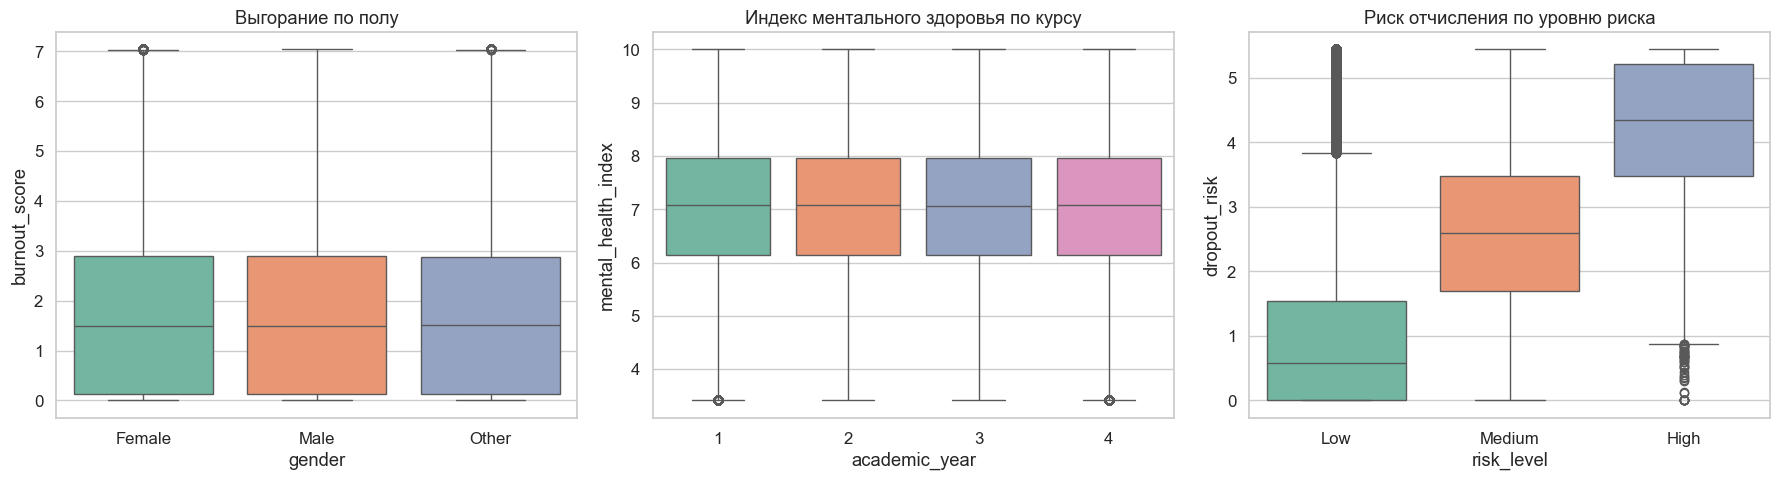

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Выгорание по полу
sns.boxplot(data=df_clean, x='gender', y='burnout_score', ax=axes[0], palette='Set2')
axes[0].set_title('Выгорание по полу')

# Индекс ментального здоровья по курсу
sns.boxplot(data=df_clean, x='academic_year', y='mental_health_index', ax=axes[1], palette='Set2')
axes[1].set_title('Индекс ментального здоровья по курсу')

# Риск отчисления по уровню риска
sns.boxplot(data=df_clean, x='risk_level', y='dropout_risk', ax=axes[2],
            order=['Low', 'Medium', 'High'], palette='Set2')
axes[2].set_title('Риск отчисления по уровню риска')

plt.tight_layout()
plt.show()

### 6.5 Связь новых признаков с целевыми переменными

C:\Users\user\AppData\Local\Temp\ipykernel_3376\73235129.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='age_group', y='digital_load', ax=axes[2], palette='coolwarm')


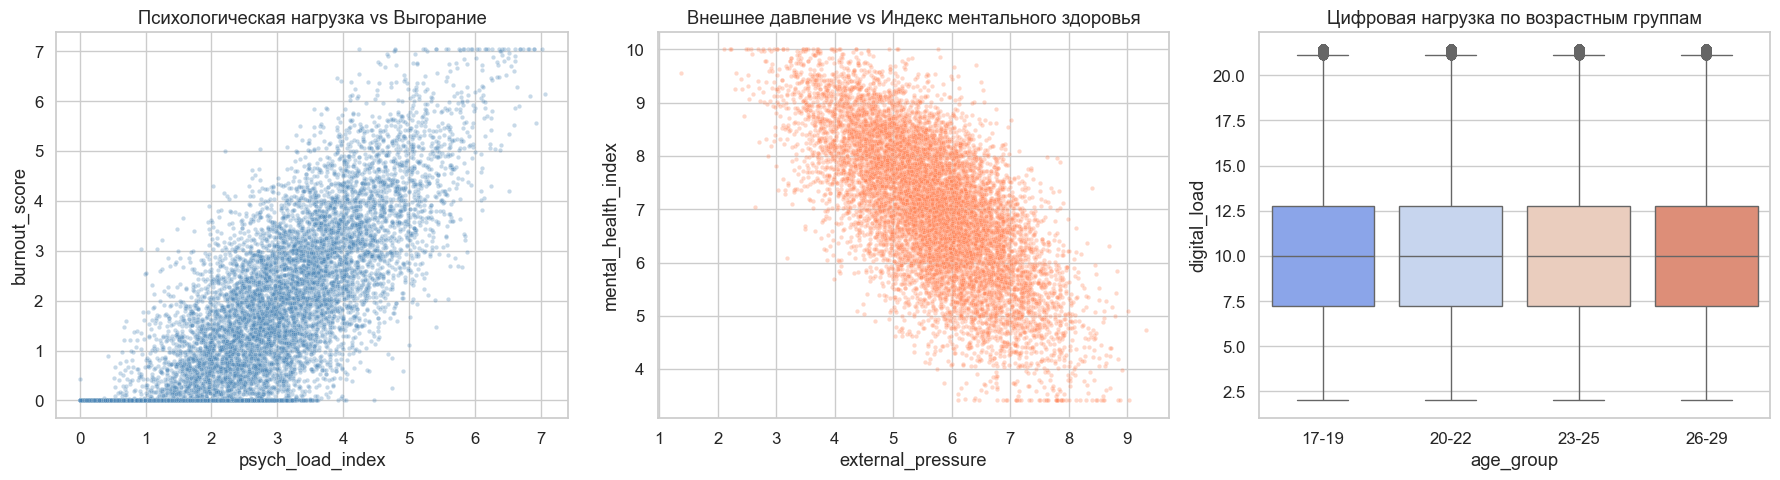

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Психологическая нагрузка vs выгорание
sns.scatterplot(data=sample, x='psych_load_index', y='burnout_score',
                alpha=0.3, s=10, ax=axes[0], color='steelblue')
axes[0].set_title('Психологическая нагрузка vs Выгорание')

# Внешнее давление vs ментальное здоровье
sns.scatterplot(data=sample, x='external_pressure', y='mental_health_index',
                alpha=0.3, s=10, ax=axes[1], color='coral')
axes[1].set_title('Внешнее давление vs Индекс ментального здоровья')

# Цифровая нагрузка по возрастным группам
sns.boxplot(data=df_clean, x='age_group', y='digital_load', ax=axes[2], palette='coolwarm')
axes[2].set_title('Цифровая нагрузка по возрастным группам')

plt.tight_layout()
plt.show()

### 6.6 Средние значения по группам риска

In [21]:
# Сводная таблица средних по группам риска
risk_summary = df_clean.groupby('risk_level')[[
    'stress_level', 'anxiety_score', 'depression_score',
    'burnout_score', 'mental_health_index', 'dropout_risk',
    'sleep_hours', 'study_hours_per_day', 'social_support'
]].mean().round(2)

risk_summary = risk_summary.reindex(['Low', 'Medium', 'High'])
print('Средние значения по группам риска:')
risk_summary

Средние значения по группам риска:


C:\Users\user\AppData\Local\Temp\ipykernel_3376\3145157759.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_summary = df_clean.groupby('risk_level')[[


,stress_level,anxiety_score,depression_score,burnout_score,mental_health_index,dropout_risk,sleep_hours,study_hours_per_day,social_support
risk_level,,,,,,,,,
Low,3.71,2.56,0.93,1.04,7.47,0.90,6.73,4.72,5.19
Medium,5.88,4.29,2.33,4.04,5.66,2.59,5.79,5.86,4.41
High,7.51,5.62,3.61,6.57,4.26,4.20,5.09,6.75,3.77


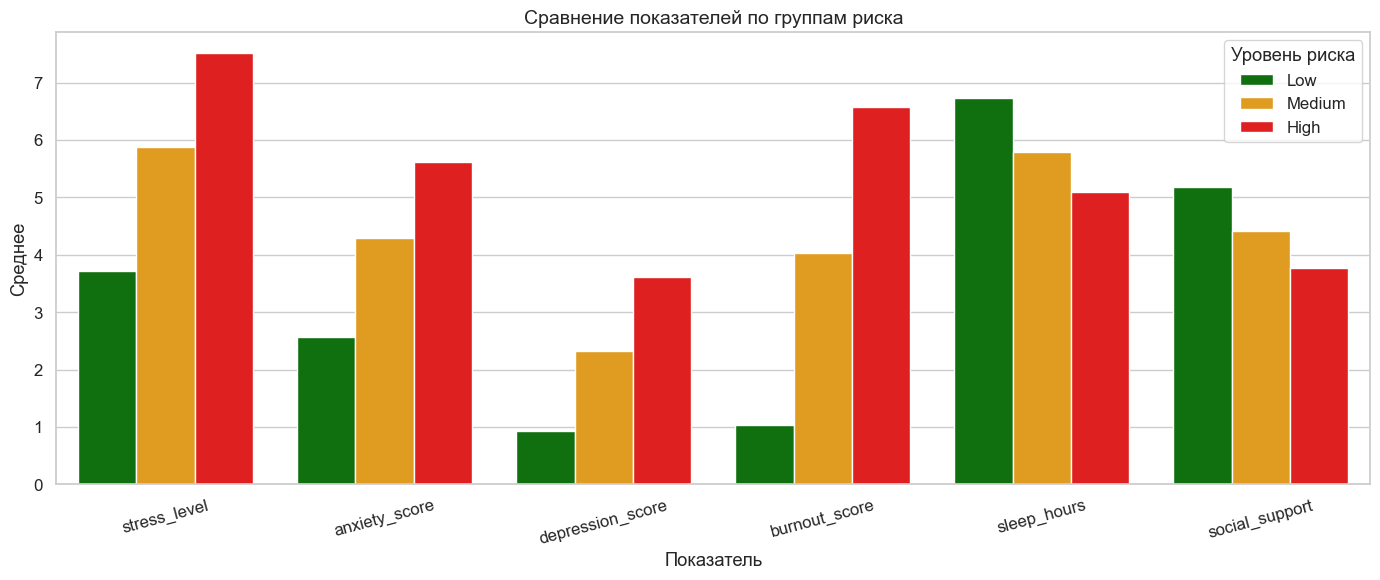

In [22]:
# Визуализация: сравнение групп риска
compare_cols = ['stress_level', 'anxiety_score', 'depression_score',
                'burnout_score', 'sleep_hours', 'social_support']

risk_melted = risk_summary[compare_cols].reset_index().melt(
    id_vars='risk_level', var_name='Показатель', value_name='Среднее'
)

plt.figure(figsize=(14, 6))
sns.barplot(data=risk_melted, x='Показатель', y='Среднее', hue='risk_level',
            hue_order=['Low', 'Medium', 'High'],
            palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'})
plt.title('Сравнение показателей по группам риска', fontsize=14)
plt.xticks(rotation=15)
plt.legend(title='Уровень риска')
plt.tight_layout()
plt.show()

### 6.7 Pairplot: ключевые переменные

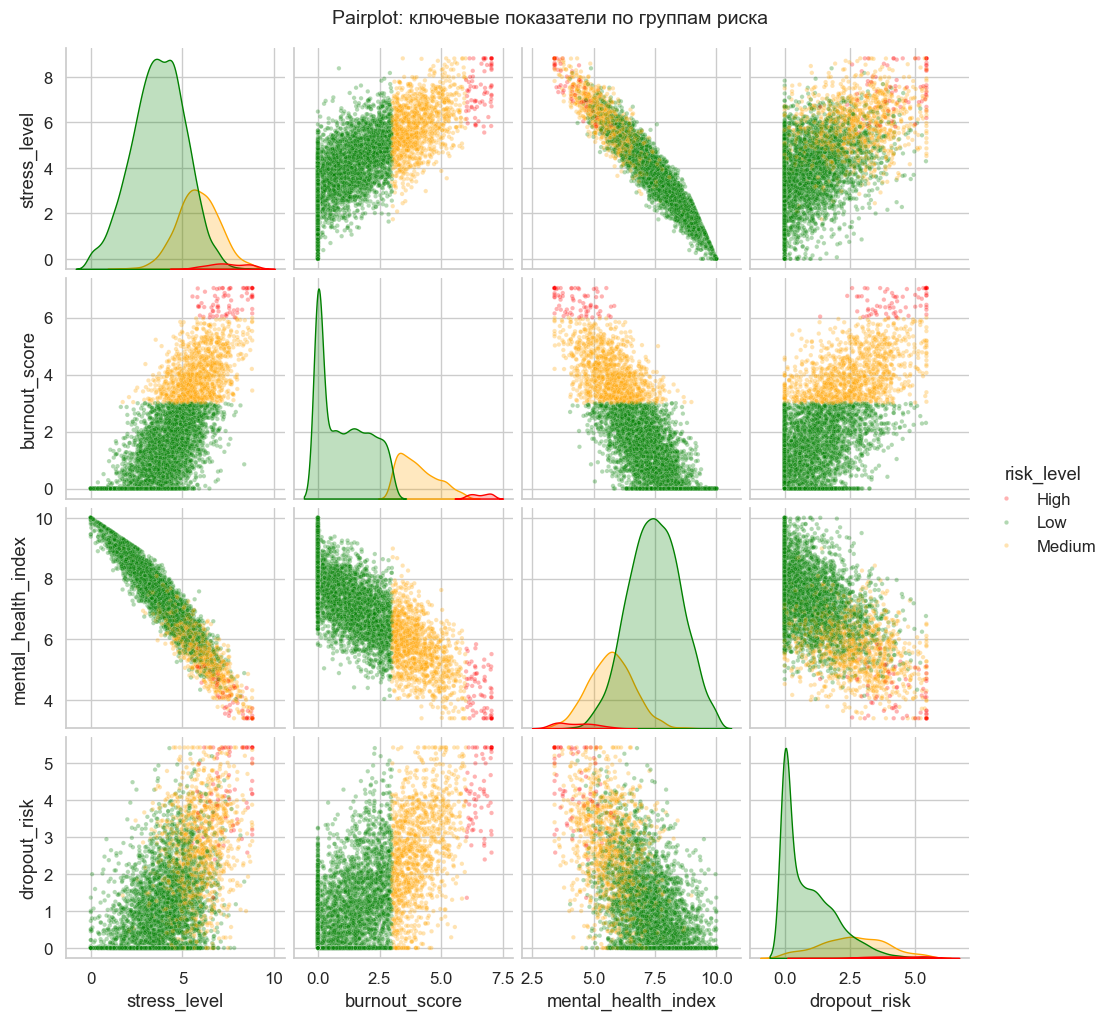

In [23]:
pairplot_sample = df_clean[['stress_level', 'burnout_score', 'mental_health_index',
                             'dropout_risk', 'risk_level']].sample(n=5000, random_state=42)

sns.pairplot(pairplot_sample, hue='risk_level',
             palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'},
             plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot: ключевые показатели по группам риска', y=1.02, fontsize=14)
plt.show()

## 7. Аналитические выводы

### Вывод 1: Стресс, тревожность и депрессия — главные предикторы выгорания
Корреляционный анализ показывает, что `stress_level`, `anxiety_score` и `depression_score` имеют наиболее сильную положительную корреляцию с `burnout_score`. Созданный агрегированный признак `psych_load_index` также демонстрирует высокую связь с выгоранием, что подтверждает: психологическое состояние студента — ключевой фактор выгорания.

### Вывод 2: Индекс ментального здоровья обратно связан с выгоранием
`mental_health_index` и `burnout_score` показывают отрицательную корреляцию: чем выше выгорание, тем ниже общий индекс ментального здоровья. Студенты из группы High-risk имеют значительно более низкий `mental_health_index`, чем студенты из группы Low-risk.

### Вывод 3: Социальная поддержка — защитный фактор
Студенты с высоким уровнем `social_support` демонстрируют более низкие показатели выгорания и риска отчисления. Социальная поддержка отрицательно коррелирует со стрессом и депрессией, что делает её одним из ключевых защитных факторов.

### Вывод 4: Нет значимых различий в выгорании между полами
Boxplot-анализ по полу показывает, что распределения `burnout_score` для Male, Female и Other практически идентичны — пол не является значимым предиктором выгорания в данном датасете.

### Вывод 5: Курс обучения слабо влияет на ментальное здоровье
Средние значения `mental_health_index` и `burnout_score` остаются стабильными по курсам (1–4), что указывает на то, что проблема выгорания не зависит от стажа обучения и актуальна для студентов всех курсов.

### Вывод 6: Группа High-risk — чёткий профиль
Студенты из группы высокого риска характеризуются комбинацией: высокий стресс + высокая тревожность + высокая депрессия + низкая социальная поддержка + недостаточный сон. Этот профиль может использоваться для раннего выявления студентов, нуждающихся в психологической помощи.

### Вывод 7: Цифровая нагрузка слабо связана с выгоранием
Признак `digital_load` (экранное время + интернет-использование) демонстрирует слабую корреляцию с выгоранием и ментальным здоровьем, что указывает на то, что время за экраном само по себе не является значимым фактором риска в данной выборке.

## Итог

В ходе работы был выполнен полный цикл исследовательского анализа данных:

1. **Загрузка и обзор** — датасет содержит 1 000 000 записей, 20 признаков, пропуски отсутствуют.
2. **Анализ выбросов** — применены методы IQR и Z-score, выявлены выбросы в `depression_score`, `burnout_score`, `dropout_risk` и других признаках.
3. **Очистка** — удалены дубликаты, выбросы ограничены методом winsorization, оптимизированы типы данных.
4. **Feature engineering** — созданы 5 новых признаков: `psych_load_index`, `sleep_study_ratio`, `digital_load`, `external_pressure`, `age_group`.
5. **Визуальный анализ** — построены гистограммы, boxplot, scatter-plot, heatmap корреляций, pairplot, barplot.
6. **Выводы** — сформулировано 7 аналитических выводов о факторах выгорания студентов.